## *Data Collection + Preprocessing and Organization*


Note : Quick Draw dataset has 345 class which is much bigger so hear iam going with 45 classes first and 5000 samples per class which gives a good demo and material for error analysis. 

In [1]:
from os import path
# importing libraries

import requests
import numpy as np
from pathlib import Path
from PIL import Image

# setting path to data folder
data_path = Path("data/")
image_path = data_path / "quickdraw"
raw_path = data_path / "raw"  # temporary folder for big .npy files

categories = [
    "cat", "tiger", "lion", "dog", "bear", "rabbit", "horse", "elephant",
    "giraffe", "butterfly", "fish", "snake", "whale", "dolphin", "shark",
    "apple", "pear", "banana", "pizza", "ice cream", "donut", "birthday cake",
    "hamburger", "bicycle", "car", "bus", "airplane", "chair", "clock",
    "umbrella", "light bulb", "scissors", "guitar", "key", "sun", "moon",
    "cloud", "tree", "star", "eye", "hand", "shoe", "hat", "house", "smiley face"
]

samples_per_class = 5000
train_split = 0.8
base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
rng = np.random.default_rng(42)

image_path.mkdir(parents= True, exist_ok= True)
raw_path.mkdir(parents= True, exist_ok= True)

for name in categories:
  label = name.replace('', '_')

  # skip categories that are already done
  if (image_path / "test" / label).is_dir():
    print(f'{label} already exists skipping.....')
    continue

  # download the .npy file for categories
  print(f'downloading {name} data.......')
  request = requests.get(base_url + name.replace(" ", "%20") + ".npy")
  request.raise_for_status()
  raw_file = raw_path / f'{label}.npy'
  with open(raw_file, 'wb') as f:
    f.write(request.content)

  # picking a random subset and reshaping from (n, 784) -> (n, 28, 28)
  data = np.load(raw_file)
  idx = rng.choice(len(data), size=min(samples_per_class, len(data)), replace= False)
  data = data[idx].reshape(-1, 28, 28)

  n_train = int(len(data) * train_split)
  for split, arr in [("train", data[:n_train]), ("test", data[n_train:])]:
    class_dir = image_path / split / label
    class_dir.mkdir(parents= True, exist_ok= True)
    for i, img in enumerate(arr):
      Image.fromarray(img).save(class_dir / f"{label}_{i}.png")

  raw_file.unlink()

print("done")

_c_a_t_ already exists skipping.....
_t_i_g_e_r_ already exists skipping.....
_l_i_o_n_ already exists skipping.....
_d_o_g_ already exists skipping.....
_b_e_a_r_ already exists skipping.....
_r_a_b_b_i_t_ already exists skipping.....
_h_o_r_s_e_ already exists skipping.....
_e_l_e_p_h_a_n_t_ already exists skipping.....
_g_i_r_a_f_f_e_ already exists skipping.....
_b_u_t_t_e_r_f_l_y_ already exists skipping.....
_f_i_s_h_ already exists skipping.....
_s_n_a_k_e_ already exists skipping.....
_w_h_a_l_e_ already exists skipping.....
_d_o_l_p_h_i_n_ already exists skipping.....
_s_h_a_r_k_ already exists skipping.....
_a_p_p_l_e_ already exists skipping.....
_p_e_a_r_ already exists skipping.....
_b_a_n_a_n_a_ already exists skipping.....
_p_i_z_z_a_ already exists skipping.....
_i_c_e_ _c_r_e_a_m_ already exists skipping.....
_d_o_n_u_t_ already exists skipping.....
_b_i_r_t_h_d_a_y_ _c_a_k_e_ already exists skipping.....
_h_a_m_b_u_r_g_e_r_ already exists skipping.....
_b_i_c_y_c_l_e_

In [2]:
# setting train & test directories

train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/quickdraw/train'), PosixPath('data/quickdraw/test'))

## *Exploring random image form the data*

In [3]:
# importing libraries
import random
from PIL import Image

random.seed(42)

# Extracting all image paths from the data...
image_path_list = list(image_path.glob("*/*/*.png"))

# picking one random image path from image path lists...
random_image_path = random.choice(image_path_list)

# extracting the class of random image path...
image_class = random_image_path.parent.stem

image_pil = Image.open(random_image_path)

print(f'random image path: {random_image_path}')
print(f'image class: {image_class}')
print(f'image height: {image_pil.height}')
print(f'image width: {image_pil.width}')
image_pil

random image path: data/quickdraw/train/_d_o_n_u_t_/_d_o_n_u_t__889.png
image class: _d_o_n_u_t_
image height: 28
image width: 28


## *Creating simple transform (without any data augmentation)*

Note : here first am going to create a baseline model with simple structure for comparing different models performences based on their structure and impovments 

In [ ]:
# importing libraries
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transform_simple = transforms.Compose([
    # here am not using transforms.resize() it has 28,28 size 
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [5]:
data_transform_simple(image_pil)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1804,
          0.4980, 0.7725, 0.9176, 0.8667, 0.8667, 0.8667, 0.7922, 0.6863,
          0.5569, 0.4235, 0.2824, 0.0353, 0.0000, 0.0000,

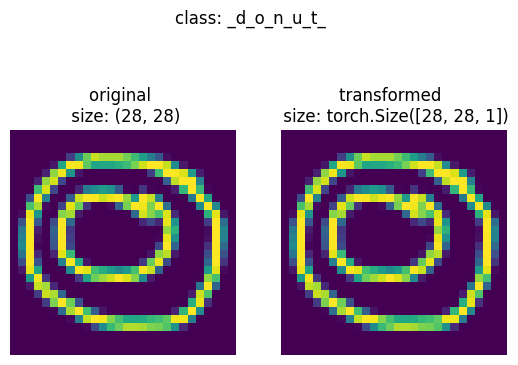

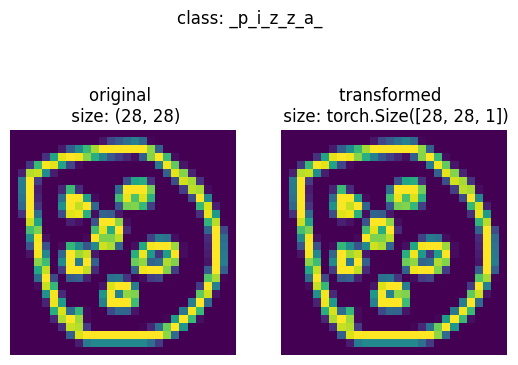

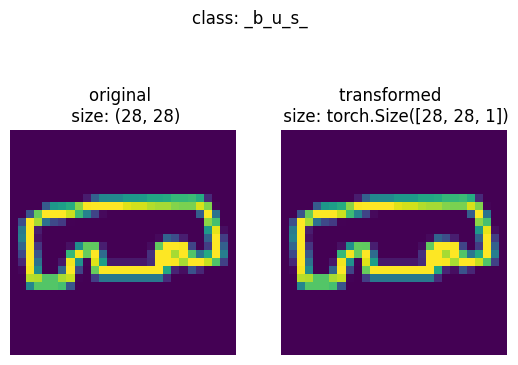

In [6]:
# Visualizing the transformed data

import matplotlib.pyplot as plt

def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"original \n size: {f.size}")
      ax[0].axis(False)

      transformed_img = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_img)
      ax[1].set_title(f"transformed \n size: {transformed_img.shape}")
      ax[1].axis(False)

      fig.suptitle(f'class: {image_path.parent.stem}')

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform_simple,
                        n=3,
                        seed=42)

In [7]:
# loadiing data
train_data_simple = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform_simple,
                                  target_transform=None)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform_simple)

print(f'train data:\n {train_data_simple}\ntest data:\n {test_data_simple}')

train data:
 Dataset ImageFolder
    Number of datapoints: 180000
    Root location: data/quickdraw/train
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )
test data:
 Dataset ImageFolder
    Number of datapoints: 45000
    Root location: data/quickdraw/test
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )


In [8]:
class_names = train_data_simple.classes
class_names

['_a_i_r_p_l_a_n_e_',
 '_a_p_p_l_e_',
 '_b_a_n_a_n_a_',
 '_b_e_a_r_',
 '_b_i_c_y_c_l_e_',
 '_b_i_r_t_h_d_a_y_ _c_a_k_e_',
 '_b_u_s_',
 '_b_u_t_t_e_r_f_l_y_',
 '_c_a_r_',
 '_c_a_t_',
 '_c_h_a_i_r_',
 '_c_l_o_c_k_',
 '_c_l_o_u_d_',
 '_d_o_g_',
 '_d_o_l_p_h_i_n_',
 '_d_o_n_u_t_',
 '_e_l_e_p_h_a_n_t_',
 '_e_y_e_',
 '_f_i_s_h_',
 '_g_i_r_a_f_f_e_',
 '_g_u_i_t_a_r_',
 '_h_a_m_b_u_r_g_e_r_',
 '_h_a_n_d_',
 '_h_a_t_',
 '_h_o_r_s_e_',
 '_h_o_u_s_e_',
 '_i_c_e_ _c_r_e_a_m_',
 '_k_e_y_',
 '_l_i_g_h_t_ _b_u_l_b_',
 '_l_i_o_n_',
 '_m_o_o_n_',
 '_p_e_a_r_',
 '_p_i_z_z_a_',
 '_r_a_b_b_i_t_',
 '_s_c_i_s_s_o_r_s_',
 '_s_h_a_r_k_',
 '_s_h_o_e_',
 '_s_m_i_l_e_y_ _f_a_c_e_',
 '_s_n_a_k_e_',
 '_s_t_a_r_',
 '_s_u_n_',
 '_t_i_g_e_r_',
 '_t_r_e_e_',
 '_u_m_b_r_e_l_l_a_',
 '_w_h_a_l_e_']

In [9]:
class_dic = train_data_simple.class_to_idx
class_dic

{'_a_i_r_p_l_a_n_e_': 0,
 '_a_p_p_l_e_': 1,
 '_b_a_n_a_n_a_': 2,
 '_b_e_a_r_': 3,
 '_b_i_c_y_c_l_e_': 4,
 '_b_i_r_t_h_d_a_y_ _c_a_k_e_': 5,
 '_b_u_s_': 6,
 '_b_u_t_t_e_r_f_l_y_': 7,
 '_c_a_r_': 8,
 '_c_a_t_': 9,
 '_c_h_a_i_r_': 10,
 '_c_l_o_c_k_': 11,
 '_c_l_o_u_d_': 12,
 '_d_o_g_': 13,
 '_d_o_l_p_h_i_n_': 14,
 '_d_o_n_u_t_': 15,
 '_e_l_e_p_h_a_n_t_': 16,
 '_e_y_e_': 17,
 '_f_i_s_h_': 18,
 '_g_i_r_a_f_f_e_': 19,
 '_g_u_i_t_a_r_': 20,
 '_h_a_m_b_u_r_g_e_r_': 21,
 '_h_a_n_d_': 22,
 '_h_a_t_': 23,
 '_h_o_r_s_e_': 24,
 '_h_o_u_s_e_': 25,
 '_i_c_e_ _c_r_e_a_m_': 26,
 '_k_e_y_': 27,
 '_l_i_g_h_t_ _b_u_l_b_': 28,
 '_l_i_o_n_': 29,
 '_m_o_o_n_': 30,
 '_p_e_a_r_': 31,
 '_p_i_z_z_a_': 32,
 '_r_a_b_b_i_t_': 33,
 '_s_c_i_s_s_o_r_s_': 34,
 '_s_h_a_r_k_': 35,
 '_s_h_o_e_': 36,
 '_s_m_i_l_e_y_ _f_a_c_e_': 37,
 '_s_n_a_k_e_': 38,
 '_s_t_a_r_': 39,
 '_s_u_n_': 40,
 '_t_i_g_e_r_': 41,
 '_t_r_e_e_': 42,
 '_u_m_b_r_e_l_l_a_': 43,
 '_w_h_a_l_e_': 44}

In [10]:
image , label = train_data_simple[0]
image, label
print(f'image shape: {image.shape}')
print(f'label : {class_names[label]}')
print(f'image dtype : {image.dtype}')
print(f'label dtype : {type(label)}')

image shape: torch.Size([1, 28, 28])
label : _a_i_r_p_l_a_n_e_
image dtype : torch.float32
label dtype : <class 'int'>


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

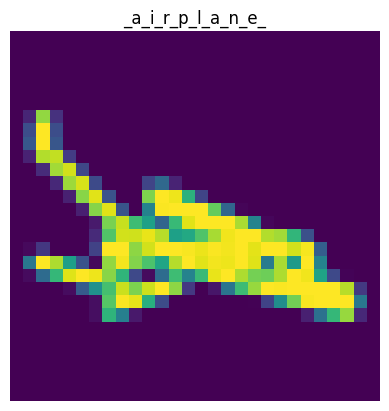

In [11]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

In [12]:
from torch.utils.data import DataLoader
import os

BATCH_SIZE = 256
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle= True)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle= False)



In [13]:
len(train_dataloader_simple), len(test_dataloader_simple)

(704, 176)

In [14]:
feature_batch, label_batch = next(iter(train_dataloader_simple))
feature_batch.shape, label_batch.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

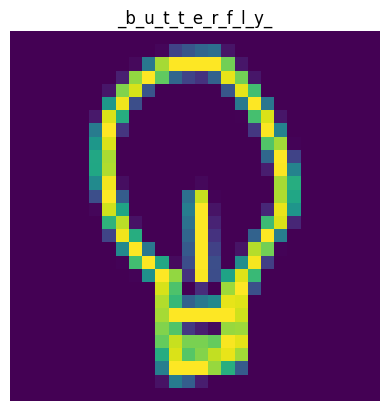

In [79]:
rand_idx = torch.randint(0, 256, size=[1]).item()
img, label = feature_batch[rand_idx], label_batch[rand_idx]
plt.imshow(img.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

In [78]:
device = 'cuda' if torch.cuda.is_available else 'cpu'
device

'cuda'

## *Creating baseline CNN model*


In [17]:
# creating tinyvgg model without data augmentation
from torch import nn

class TinyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)

    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x:torch.Tensor):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)

    return x


In [ ]:
# creating an instance of a model
model_0 = TinyVGG(input_shape=1,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=45, bias=True)
  )
)

###  Trying a forward pass on a single image (to test the model)

In [19]:
img_batch, label_batch = next(iter(train_dataloader_simple))
img_single, label_single = img_batch[0].unsqueeze(dim=0) , label_batch[0]

model_0.eval()
with torch.inference_mode():
  pred = model_0(img_single.to(device))

print(f'output logits: {pred}')
print(f'output probabilities : {torch.softmax(pred, dim=1)}')
print(f'output prediction label :{torch.argmax(torch.softmax(pred, dim=1), dim=1)}')
print(f'actual label : {label_single}')

output logits: tensor([[-0.0034, -0.0197, -0.0206,  0.0725, -0.0107, -0.0054, -0.0238, -0.0050,
         -0.0547, -0.0109,  0.0183,  0.0134, -0.0320,  0.0218, -0.0159, -0.0256,
         -0.0025, -0.0059, -0.0745, -0.0656, -0.0274,  0.0104, -0.0198,  0.0464,
          0.0507, -0.0516, -0.0406, -0.0362,  0.0466,  0.0566,  0.0106, -0.0173,
          0.0040, -0.0228, -0.0072,  0.0357, -0.0002, -0.0239, -0.0110,  0.0650,
          0.0209, -0.0188,  0.0474, -0.0099,  0.0295]], device='cuda:0')
output probabilities : tensor([[0.0222, 0.0218, 0.0218, 0.0239, 0.0220, 0.0221, 0.0217, 0.0222, 0.0211,
         0.0220, 0.0227, 0.0226, 0.0216, 0.0228, 0.0219, 0.0217, 0.0222, 0.0221,
         0.0207, 0.0209, 0.0217, 0.0225, 0.0218, 0.0233, 0.0234, 0.0211, 0.0214,
         0.0215, 0.0233, 0.0236, 0.0225, 0.0219, 0.0224, 0.0218, 0.0221, 0.0231,
         0.0223, 0.0217, 0.0220, 0.0238, 0.0227, 0.0219, 0.0233, 0.0220, 0.0229]],
       device='cuda:0')
output prediction label :tensor([3], device='cuda:0')

Note : here there is a missmatch of prediction label and actual label because the model hasn't been trained yet and it's essentially guessing using random weights.

In [20]:
from sklearn.metrics import accuracy_score

def accuracy_fn(y_true, y_pred):
  return accuracy_score(y_true.cpu(), y_pred.cpu())

## creating functions for training and testing loops

In [21]:
def train_step(model: torch.nn.Module,
                  dataloader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  optimizer: torch.optim.Optimizer,
                  accuracy_fn):
  model.train()

  train_loss, train_acc = 0,0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    acc = accuracy_fn(y, y_pred.argmax(dim=1))
    train_acc += acc

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [22]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn):
  model.eval()

  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred = model(X)
      loss = loss_fn(test_pred, y)
      test_loss += loss.item()

      acc = accuracy_fn(y, test_pred.argmax(dim=1))
      test_acc += acc

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)
  return test_loss, test_acc

In [23]:
def train(model: torch.nn.Module,
          TrainDataLoader: torch.utils.data.DataLoader,
          TestDataLoader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          accuracy_fn):
  results = {
      'train_loss' : [],
      'train_acc': [],
      'test_loss': [],
      'test_acc': []
  }

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader= TrainDataLoader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       accuracy_fn=accuracy_fn)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=TestDataLoader,
                                    loss_fn=loss_fn,
                                    accuracy_fn=accuracy_fn)

    print(
        f"epoch: {epoch+1} |"
        f"train_loss: {train_loss:.4f} |"
        f"train_acc: {train_acc:.4f} |"
        f"test_loss: {test_loss:.4f} |"
        f"test_acc: {test_acc:.4f}"
    )

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

In [24]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 10

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

start_time = timer()
model_0_results = train(model=model_0,
                        TrainDataLoader= train_dataloader_simple,
                        TestDataLoader= test_dataloader_simple,
                        loss_fn= loss_fn,
                        optimizer=optimizer,
                        accuracy_fn=accuracy_fn,
                        epochs=NUM_EPOCHS)
end_time = timer()
print(f'total Train Time:\n {end_time - start_time:.2f} seconds')

  0%|          | 0/10 [00:00<?, ?it/s]

epoch: 1 |train_loss: 1.6423 |train_acc: 0.5782 |test_loss: 1.1959 |test_acc: 0.6932
epoch: 2 |train_loss: 1.0828 |train_acc: 0.7219 |test_loss: 1.0358 |test_acc: 0.7325
epoch: 3 |train_loss: 0.9739 |train_acc: 0.7489 |test_loss: 0.9632 |test_acc: 0.7526
epoch: 4 |train_loss: 0.9124 |train_acc: 0.7641 |test_loss: 0.9253 |test_acc: 0.7596
epoch: 5 |train_loss: 0.8742 |train_acc: 0.7734 |test_loss: 0.9005 |test_acc: 0.7665
epoch: 6 |train_loss: 0.8453 |train_acc: 0.7800 |test_loss: 0.8800 |test_acc: 0.7703
epoch: 7 |train_loss: 0.8231 |train_acc: 0.7850 |test_loss: 0.8600 |test_acc: 0.7770
epoch: 8 |train_loss: 0.8059 |train_acc: 0.7889 |test_loss: 0.8389 |test_acc: 0.7799
epoch: 9 |train_loss: 0.7932 |train_acc: 0.7923 |test_loss: 0.8683 |test_acc: 0.7714
epoch: 10 |train_loss: 0.7808 |train_acc: 0.7950 |test_loss: 0.8241 |test_acc: 0.7841
total Train Time:
 526.15 seconds


In [25]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

### ploting loss curves 

In [26]:
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results['train_loss']
    test_loss = results['test_loss']

    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15,7))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('loss')
    plt.xlabel('epochs')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('accuracy')
    plt.xlabel('epochs')
    plt.legend();

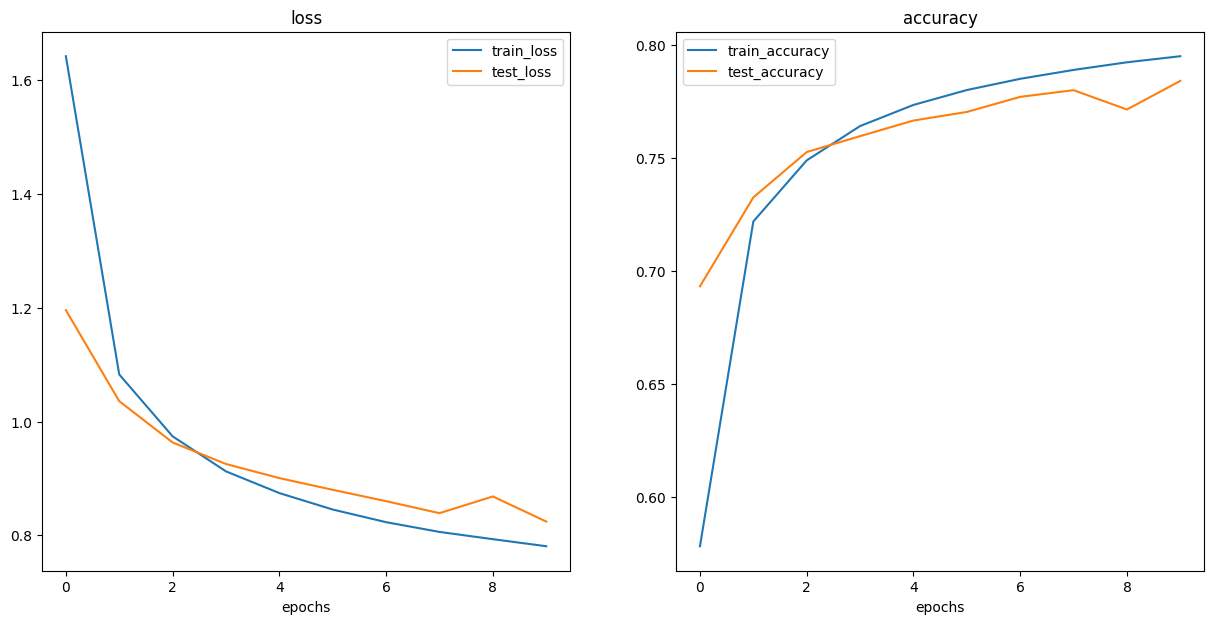

In [27]:
plot_loss_curves(model_0_results)

conclusion: Train and test loss both decrease steadily while accuracy rices to above 78% with two curves staying together, so model generalizes well with no significant overfitting. since the curves haven't flattened yet, training for more epochsshould improve performance further.

### Confusion matrix

In [28]:
from tqdm.auto import tqdm

y_preds = []
model_0.eval()
with torch.inference_mode():
  for X , y in tqdm(test_dataloader_simple, desc="Making predictions"):
    X, y = X.to(device), y.to(device)

    y_logits = model_0(X)

    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

y_preds_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/176 [00:00<?, ?it/s]

In [ ]:
# !pip install -q --force-reinstall scikit-learn

In [ ]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics

In [30]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.4


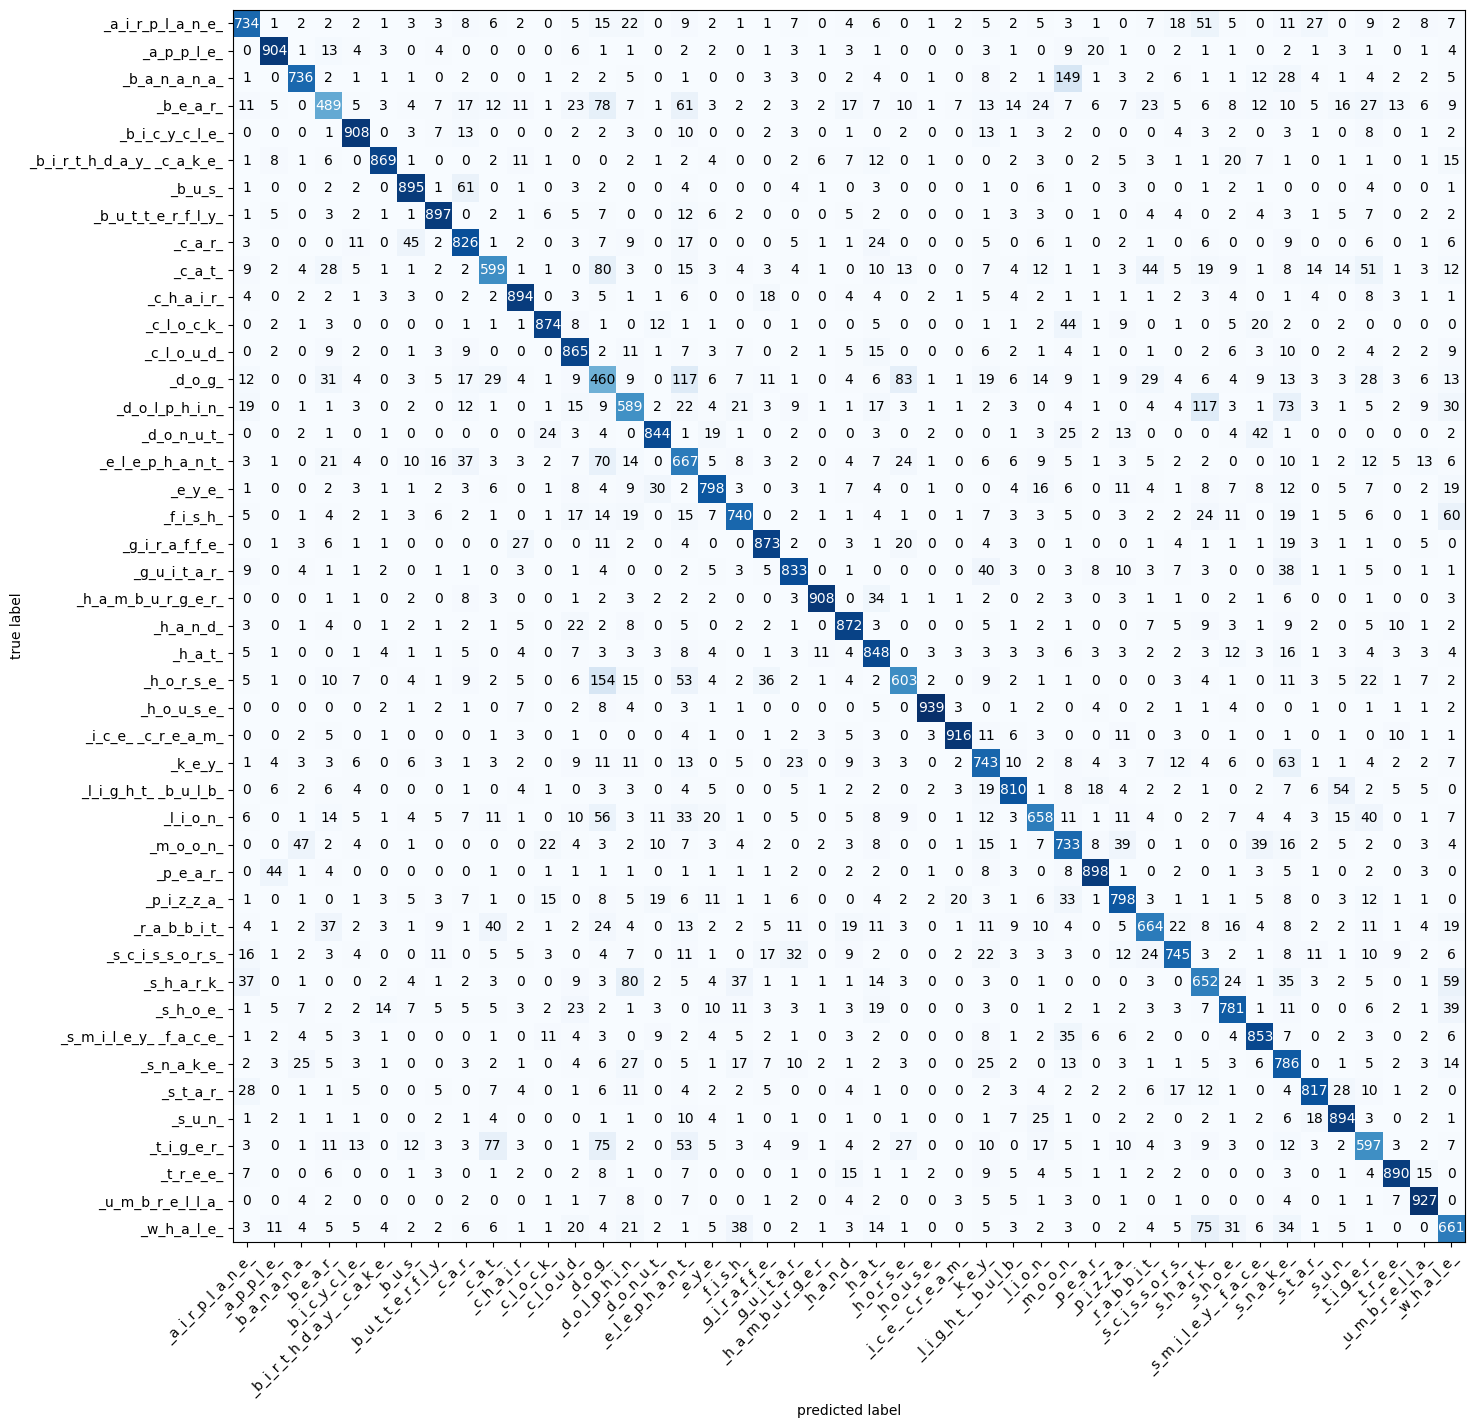

In [34]:
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix

confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_preds_tensor, target=torch.tensor(test_data_simple.targets))

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.cpu().numpy(),
                                class_names=class_names,
                                figsize=(18,16));

## *Creating better model (Combines increased capacity, longer training and augmentation)*

In [ ]:
# Creating transform with data augmentation

from math import degrees
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

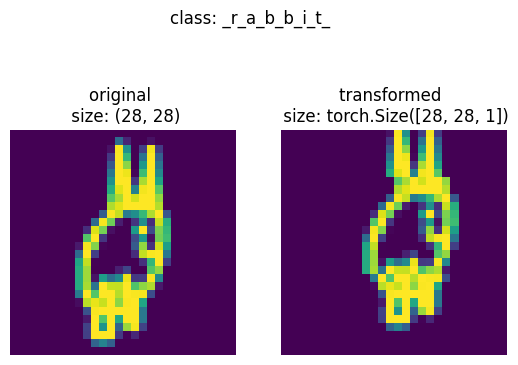

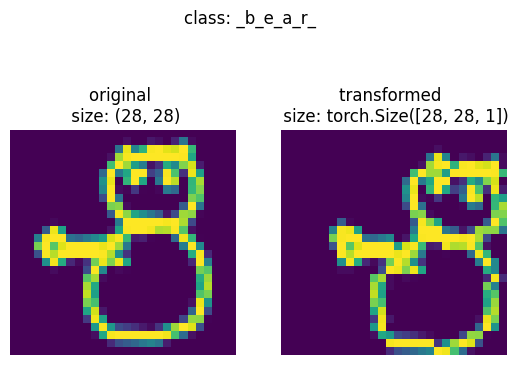

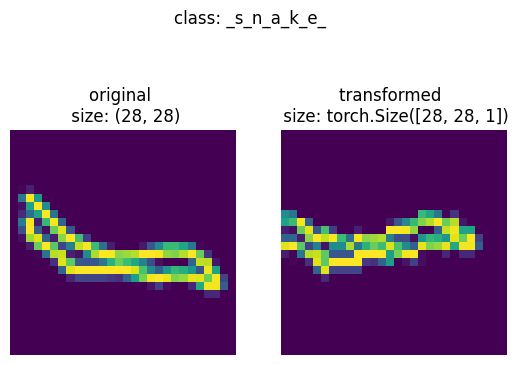

In [36]:
plot_transformed_images(image_paths=image_path_list,
                        transform=train_transform,
                        n=3,
                        seed=3)

In [37]:
# loading data
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=train_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=test_transform)

print(f'train data:\n {train_data}\ntest data:\n {test_data}')

train data:
 Dataset ImageFolder
    Number of datapoints: 180000
    Root location: data/quickdraw/train
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
               ToTensor()
           )
test data:
 Dataset ImageFolder
    Number of datapoints: 45000
    Root location: data/quickdraw/test
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
           )


In [38]:
from torch.utils.data import DataLoader
import os

Batch_size = 256
Num_workers = os.cpu_count()

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=Batch_size,
                              num_workers=Num_workers,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=Batch_size,
                             num_workers=Num_workers,
                             shuffle=False)

In [39]:
len(train_dataloader), len(test_dataloader)

(704, 176)

In [40]:
featurebatch, labelbatch = next(iter(train_dataloader))
featurebatch.shape, labelbatch.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

In [41]:
# creating new and better model_1
from torch import nn

class TinyVGG2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)

    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x:torch.Tensor):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)

    return x

In [ ]:
# creating model instance
model_1 = TinyVGG2(input_shape=1,
                   hidden_units=32,
                   output_shape=len(class_names)).to(device)
model_1

TinyVGG2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=45, bias=True)
  )
)

In [43]:
new_img, new_label = next(iter(train_dataloader))
new_img_single, new_label_single = new_img[0].unsqueeze(dim=0), new_label[0]

model_1.eval()
with torch.inference_mode():
  Pred = model_1(new_img_single.to(device))

print(f'output logits: {Pred}')
print(f'output probabilities : {torch.softmax(Pred, dim=1)}')
print(f'output prediction label :{torch.argmax(torch.softmax(Pred, dim=1), dim=1)}')
print(f'actual label : {new_label_single}')

output logits: tensor([[ 0.0106,  0.0068, -0.0071, -0.0025, -0.0067,  0.0214,  0.0249, -0.0028,
         -0.0167,  0.0054,  0.0190,  0.0346, -0.0238,  0.0123, -0.0277, -0.0009,
          0.0187, -0.0424, -0.0050, -0.0154, -0.0059, -0.0223,  0.0175, -0.0150,
         -0.0222,  0.0220, -0.0124, -0.0421,  0.0276, -0.0352, -0.0200,  0.0104,
         -0.0298, -0.0177,  0.0297, -0.0135, -0.0351,  0.0252, -0.0066, -0.0564,
         -0.0075, -0.0242,  0.0267, -0.0328,  0.0328]], device='cuda:0')
output probabilities : tensor([[0.0226, 0.0225, 0.0222, 0.0223, 0.0222, 0.0228, 0.0229, 0.0223, 0.0219,
         0.0224, 0.0227, 0.0231, 0.0218, 0.0226, 0.0217, 0.0223, 0.0227, 0.0214,
         0.0222, 0.0220, 0.0222, 0.0218, 0.0227, 0.0220, 0.0218, 0.0228, 0.0220,
         0.0214, 0.0229, 0.0215, 0.0219, 0.0226, 0.0217, 0.0219, 0.0230, 0.0220,
         0.0215, 0.0229, 0.0222, 0.0211, 0.0222, 0.0218, 0.0229, 0.0216, 0.0231]],
       device='cuda:0')
output prediction label :tensor([11], device='cuda:0'

Note : here there is a missmatch of prediction label and actual label because the model hasn't been trained yet and it's essentially guessing using random weights.

In [ ]:
# Training model_1 with train function

from tqdm.auto import tqdm
from timeit import default_timer as timer

torch.manual_seed(42)
torch.cuda.manual_seed(42)

num_epochs = 20

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

start_time_model_1 = timer()
model_1_results = train(model=model_1,
                        TrainDataLoader=train_dataloader,
                        TestDataLoader=test_dataloader,
                        loss_fn=loss_fn,
                        optimizer=optimizer,
                        epochs=num_epochs,
                        accuracy_fn=accuracy_fn)
end_time_model_1 = timer()
print(f'total Train Time:\n {end_time_model_1 - start_time_model_1:.2f} seconds')

  0%|          | 0/20 [00:00<?, ?it/s]

epoch: 1 |train_loss: 1.7545 |train_acc: 0.5384 |test_loss: 1.0412 |test_acc: 0.7306
epoch: 2 |train_loss: 1.1504 |train_acc: 0.6967 |test_loss: 0.8424 |test_acc: 0.7791
epoch: 3 |train_loss: 0.9959 |train_acc: 0.7365 |test_loss: 0.7708 |test_acc: 0.7986
epoch: 4 |train_loss: 0.9185 |train_acc: 0.7540 |test_loss: 0.7375 |test_acc: 0.8027
epoch: 5 |train_loss: 0.8731 |train_acc: 0.7666 |test_loss: 0.7084 |test_acc: 0.8112
epoch: 6 |train_loss: 0.8424 |train_acc: 0.7730 |test_loss: 0.6843 |test_acc: 0.8178
epoch: 7 |train_loss: 0.8194 |train_acc: 0.7798 |test_loss: 0.6625 |test_acc: 0.8233
epoch: 8 |train_loss: 0.8017 |train_acc: 0.7839 |test_loss: 0.6637 |test_acc: 0.8220
epoch: 9 |train_loss: 0.7834 |train_acc: 0.7882 |test_loss: 0.6533 |test_acc: 0.8267
epoch: 10 |train_loss: 0.7663 |train_acc: 0.7927 |test_loss: 0.6403 |test_acc: 0.8304
epoch: 11 |train_loss: 0.7551 |train_acc: 0.7956 |test_loss: 0.6364 |test_acc: 0.8318
epoch: 12 |train_loss: 0.7444 |train_acc: 0.7979 |test_loss: 0.

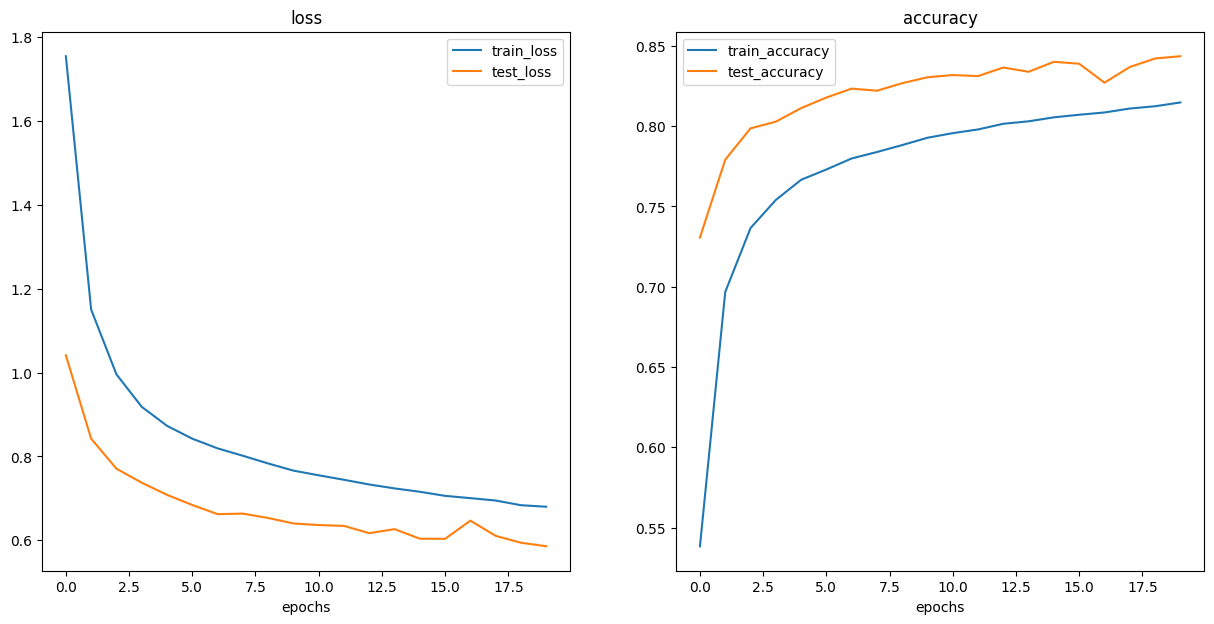

In [ ]:
# plotting loss curves
plot_loss_curves(model_1_results)

Conclusion : Model_1 trained well, test accuracy(about 84%) stays above train accuracy(about 81%), and test loss(about 0.58) stays below train loss(about 0.67). that shows no overfitting the gap comes from augmentation making the training images harder than the clean test images. both curves flatten by around epoch 15 to 19, so more epochs would add only a small gain. the dip at epoch 16 is normal noise.

In [46]:
y_preds_1 = []
model_1.eval()
with torch.inference_mode():
  for X , y in tqdm(test_dataloader, desc="Making predictions"):
    X, y = X.to(device), y.to(device)

    y_logits = model_1(X)

    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    y_preds_1.append(y_pred.cpu())

y_preds_1_tensor = torch.cat(y_preds_1)

Making predictions:   0%|          | 0/176 [00:00<?, ?it/s]

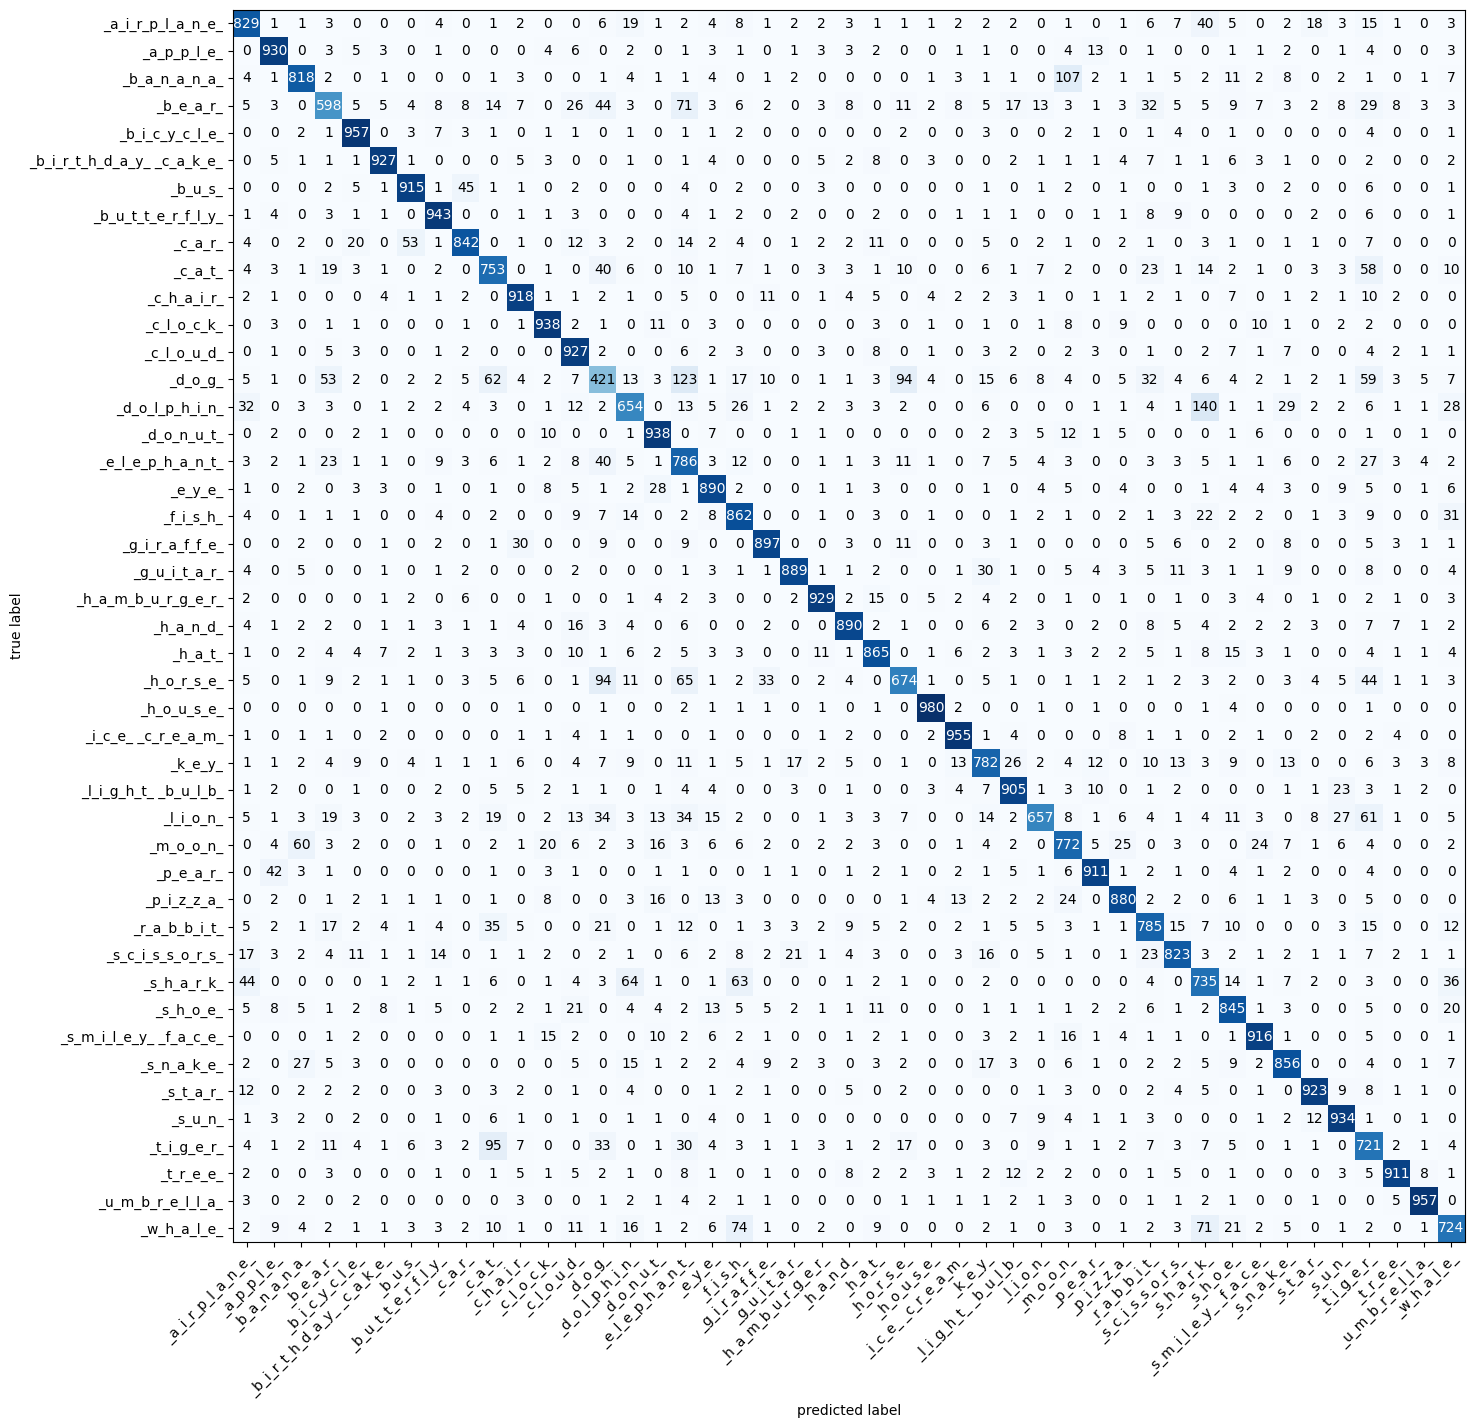

In [47]:
comfmat_1 = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor_1 = confmat(preds=y_preds_1_tensor, target=torch.tensor(test_data.targets))

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor_1.cpu().numpy(),
                                class_names=class_names,
                                figsize=(18,16));

## *Creating model_2 using Transfer Learning*

In [ ]:
#  Geting a set of pretrained model weights
import torchvision

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [ ]:
# Geting the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
# Create training and testing DataLoaders as well as get a list of class names
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transforms: transforms.Compose,
    batch_size: int,
    num_workers: int=NUM_WORKERS
):

  train_data = datasets.ImageFolder(train_dir, transform=transforms)
  test_data = datasets.ImageFolder(test_dir, transform=transforms)

  class_names = train_data.classes

  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True
  )

  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True
  )

  return train_dataloader, test_dataloader, class_names

In [51]:
train_dataloader_transfer, test_dataloader_transfer, class_names = create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transforms=auto_transforms,
    batch_size=256,
    num_workers=NUM_WORKERS
)

In [52]:
xb , yb = next(iter(train_dataloader_transfer))
xb.shape

torch.Size([256, 3, 224, 224])

### Getting a pretrained model

In [53]:
model_2 = torchvision.models.efficientnet_b0(weights=weights).to(device)

for params in model_2.features.parameters():
  params.requires_grad = False

torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

model_2.classifier = nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True)).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 190MB/s]


### Train model

In [54]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

torch.manual_seed(42)
torch.cuda.manual_seed(42)

num_epochs = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=0.001)

start_time_model_2 = timer()

model_2_results = train(model=model_2,
                        TrainDataLoader=train_dataloader_transfer,
                        TestDataLoader=test_dataloader_transfer,
                        loss_fn=loss_fn,
                        optimizer=optimizer,
                        epochs=num_epochs,
                        accuracy_fn=accuracy_fn)

end_time_model_2 = timer()
print(f'total Train Time:\n {end_time_model_2 - start_time_model_2:.2f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

epoch: 1 |train_loss: 1.4009 |train_acc: 0.6580 |test_loss: 0.9452 |test_acc: 0.7462
epoch: 2 |train_loss: 1.0285 |train_acc: 0.7239 |test_loss: 0.8634 |test_acc: 0.7658
epoch: 3 |train_loss: 0.9707 |train_acc: 0.7374 |test_loss: 0.8309 |test_acc: 0.7734
epoch: 4 |train_loss: 0.9425 |train_acc: 0.7429 |test_loss: 0.8124 |test_acc: 0.7771
epoch: 5 |train_loss: 0.9270 |train_acc: 0.7458 |test_loss: 0.8025 |test_acc: 0.7787
total Train Time:
 3426.04 seconds


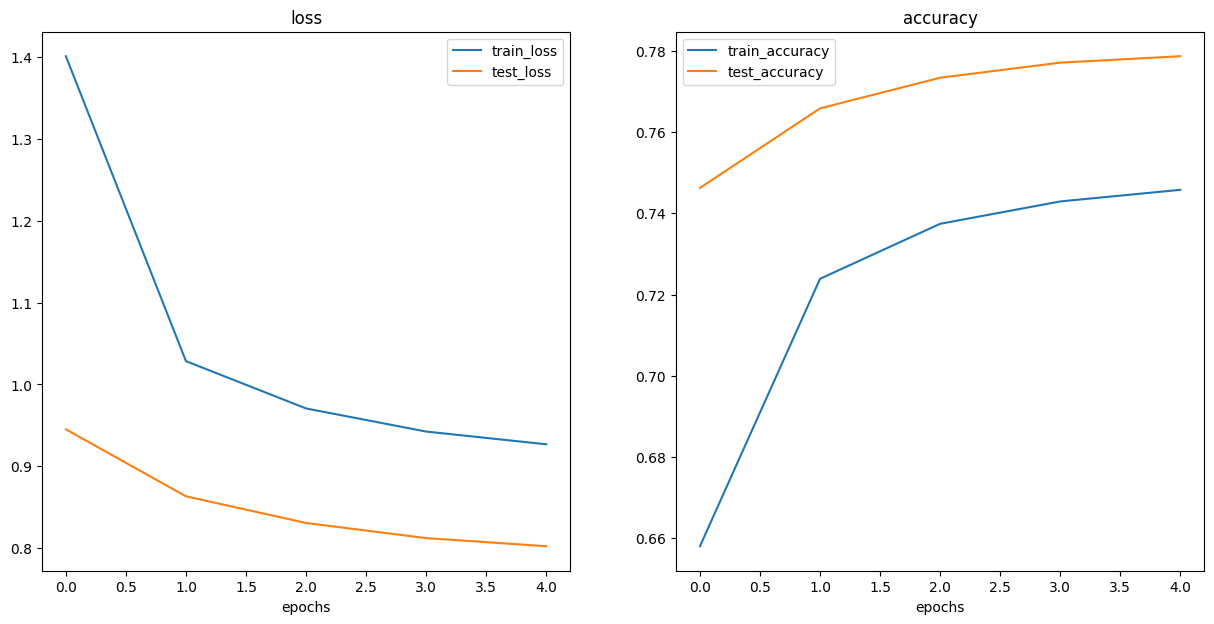

In [ ]:
# plotting loss curves 
plot_loss_curves(model_2_results)

conclusion: The training loss decreases steadily while accuracy increases from about 65% to 75%, showing that the model is learning effectively. The test loss also decreases and test accuracy reaches about 78%, indicating good generalization with no obvious overfitting.

### Creating a performance comparison df for models 0,1,2

In [72]:
import pandas as pd

def best_epoch_stats(results, name, epochs_trained):
  best_idx = results["test_loss"].index(min(results["test_loss"]))
  return {
      "Model" : name,
      "Test Accuracy": f"{results['test_acc'][best_idx]*100:.1f}%",
      "Test Loss": round(results["test_loss"][best_idx], 3),
      "best Epoch": best_idx+1,
      "Epochs Trained": epochs_trained
  }

rows = [
    best_epoch_stats(model_0_results, "model_0 (baseline CNN)", 10),
    best_epoch_stats(model_1_results, "model_1 (augmented + more capacity)", 20),
    best_epoch_stats(model_2_results, "model_2 (transfer learning, EfficientNet-B0)", 5)
]

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_markdown(index=False))

| Model                                        | Test Accuracy   |   Test Loss |   best Epoch |   Epochs Trained |
|:---------------------------------------------|:----------------|------------:|-------------:|-----------------:|
| model_0 (baseline CNN)                       | 78.4%           |       0.824 |           10 |               10 |
| model_1 (augmented + more capacity)          | 84.4%           |       0.586 |           20 |               20 |
| model_2 (transfer learning, EfficientNet-B0) | 77.9%           |       0.802 |            5 |                5 |


## *Observation*

model_1 (data augmentation, 32 hidden units, 20 epochs) is the model used in the app. It had the highest test accuracy (84.4%, 6 points above the 78.4% baseline) and the lowest test loss (0.586), and it trained in about 20-25 minutes. Transfer learning from a frozen ImageNet EfficientNet-B0 did not help (77.9%). Features learned on photographs probably transfer poorly to flat black-and-white line drawings. It was also the slowest to train, at about 11 minutes per epoch at 224×224 versus about 1.3 for model_1. model_1 is also tiny (about 0.1M parameters versus about 4M), so it predicts instantly on a CPU, which suits a live drawing app.

## Saving best performing model

In [56]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

MODEL_NAME = "DOODLE_MODEL_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

saving model to: models/DOODLE_MODEL_1.pth


In [70]:
import json

with open("models/class_names.json", "w") as f:
  json.dump(class_names, f)

### loading a model to make sure our model is saved correctly 

In [60]:
loaded_model_1 = TinyVGG2(input_shape=1,
                          hidden_units=32,
                          output_shape=45)

loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_1 = loaded_model_1.to(device)

In [73]:
def eval_mode(model: torch.nn.Module,
              dataloader: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn):
  loss,acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in dataloader:

      X, y = X.to(device), y.to(device)

      y_pred = model(X)

      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    loss /= len(dataloader)
    acc/= len(dataloader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

In [74]:
torch.manual_seed(42)

loaded_model_1_results = eval_mode(model=loaded_model_1,
                                   dataloader=test_dataloader,
                                   loss_fn=loss_fn,
                                   accuracy_fn=accuracy_fn)
loaded_model_1_results

{'model_name': 'TinyVGG2',
 'model_loss': 0.5859612822532654,
 'model_acc': 0.8435085227272728}